# Глава 1. Суточные колебания одной колонки

**LEO West · W_R4_C-4 · D1/D2/D3 · октябрь 2017**  
Dimitri Bolt · 25.09.2026 · **Расчёт выполнен**

[Оглавление](README.md) · [Подробные пояснения](details/README.md) · [Далее: глава 2, план](PLAN.md#chapter-2)

**Задача:** определить амплитуды и взаимные фазовые сдвиги суточной составляющей
трёх уровней; проверить их изменчивость по дням. Это первый пример перед
сравнением месяцев и анализом совместных траекторий.

<a id="data"></a>

## 1.1. Данные

Интервал **[01.10.2017, 01.11.2017)**, местное время базы.
Датчики D1 / D2 / D3: **994 / 1010 / 1026**, по **8846 измерений**;
шаг около 5 минут. Кодов ≤ −9999 нет; по четыре разрыва в каждом ряду.
Временные метки и всплески сохранены, пропуски не интерполируются.

[Данные и происхождение](data/ch01/README.md) · [Код и запуск](details/reproduction.md) ·
[Подробно о пропусках](details/01_methods.md#raw)

In [13]:
from pathlib import Path
import sys
project = next(p for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "Project_description/Research_log/chapter01.py").is_file())
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from Project_description.Research_log.chapter01 import load_october
report = load_october()

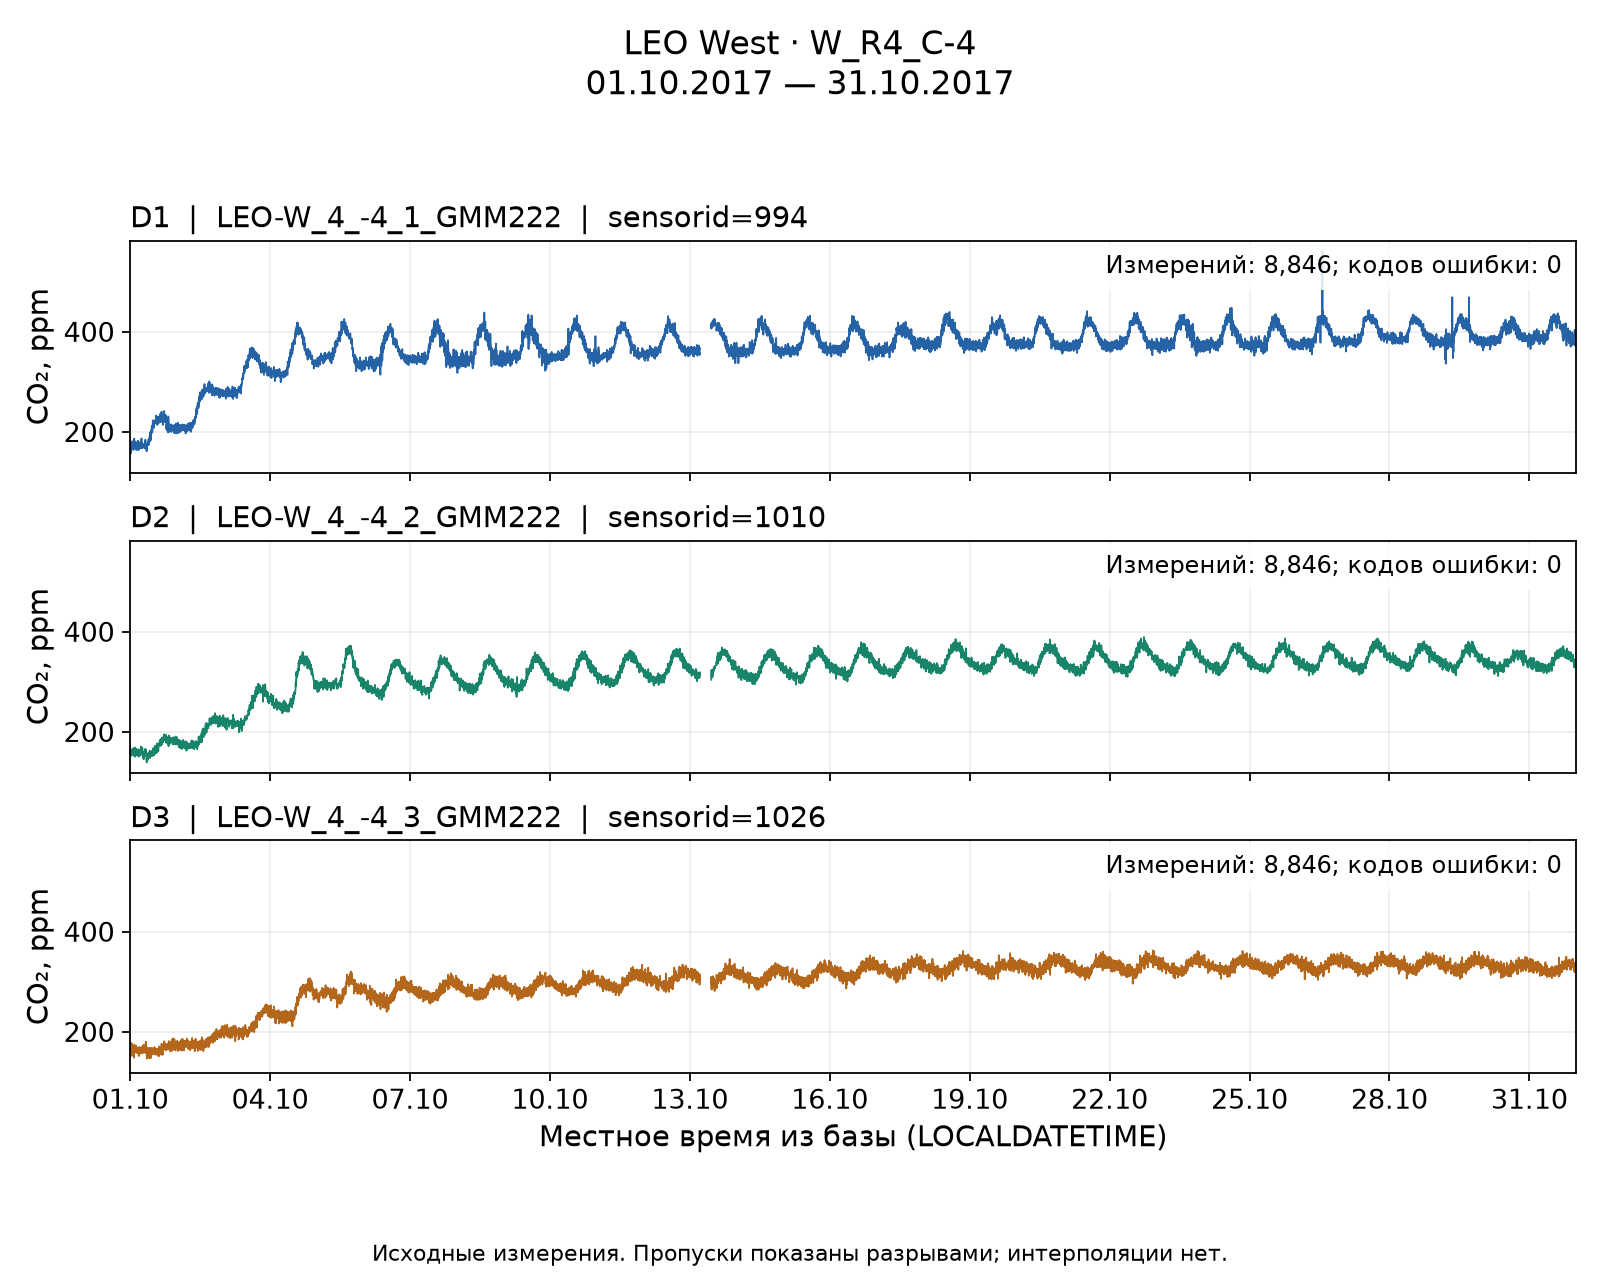

In [14]:
report.show("raw")

**Рисунок 1.1. Исходные ряды.** Начало месяца выделяется ростом общего уровня;
повторяющиеся колебания у D3 слабее. Причины роста и отдельных всплесков пока не установлены.

<a id="preparation"></a>

## 1.2. Выделение отклонений

$$m_j(t)=\frac{1}{N_j(t)}\sum_{t_i\in[t-12\,\mathrm{ч},\,t+12\,\mathrm{ч})}C_j(t_i),
\qquad r_j(t)=C_j(t)-m_j(t).$$

$N_j(t)$ - число исходных отсчётов в окне. Используются только полные окна внутри
непрерывных участков; остатки сопоставляются на общих интервалах трёх датчиков.
Получено **4 общих интервала, по 7662 остатка** для месячной подгонки.

[Подробности среднего, краёв и общих интервалов](details/01_methods.md#trend)

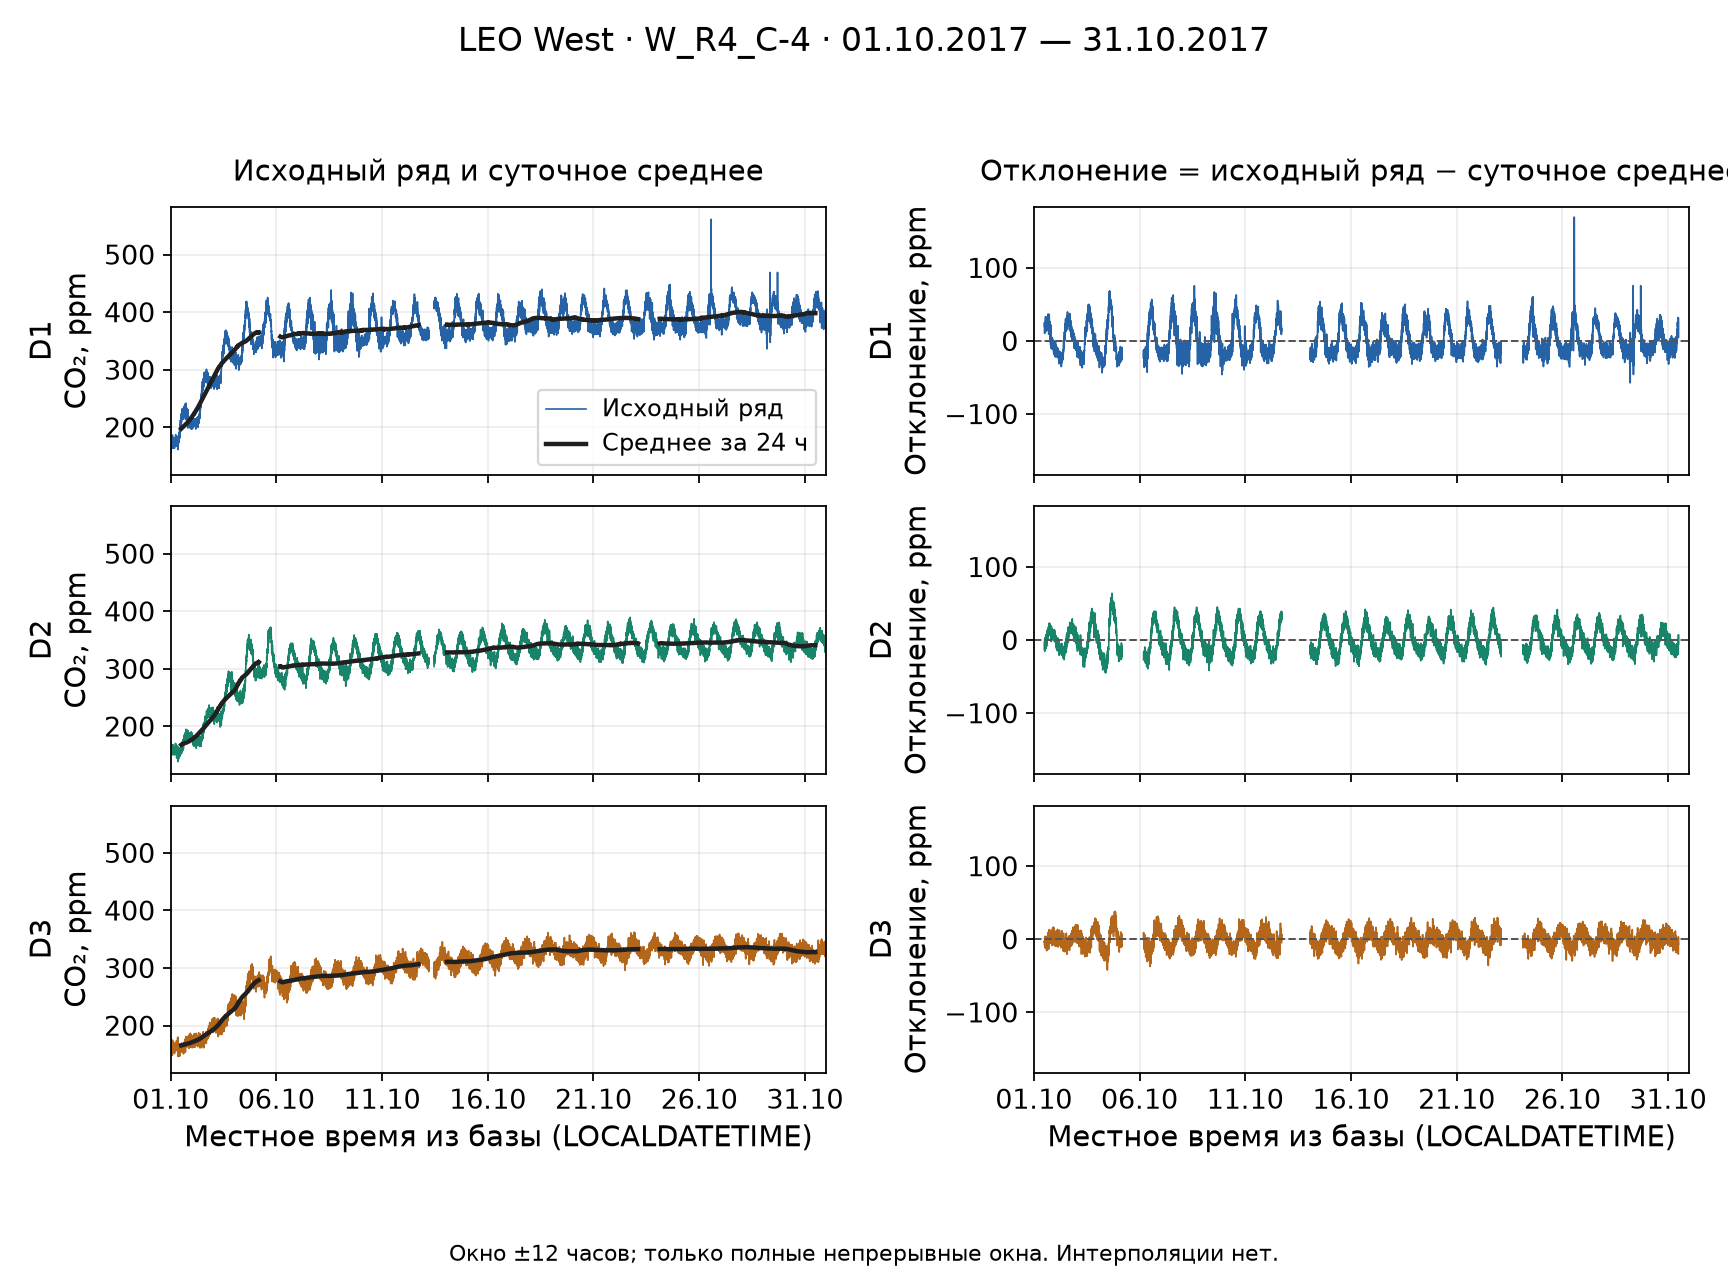

In [15]:
report.show("trend")

**Рисунок 1.2.** Слева: исходный ряд и 24-часовое среднее. Справа: остатки.
Исключения вокруг пропусков расширились на полуширину окна. Амплитуда отклонений D3 меньше.

<a id="monthly"></a>

## 1.3. Месячная суточная модель

$$\widehat r_j(t)=c_j+a_j\cos(\omega h(t))+b_j\sin(\omega h(t)),
\qquad \omega=\frac{2\pi}{24}.$$

МНК на исходных временных метках; $h(t)$ - местное время суток в часах.
Период **24 ч задан**. Амплитуда и время максимума:

$$A_j=\sqrt{a_j^2+b_j^2},\qquad h_j=\frac{\mathrm{atan2}(b_j,a_j)}{\omega}\pmod{24}.$$

[Вывод и смысл параметров](details/01_methods.md#harmonic) ·
[Определение R² и разбор значений](details/01_methods.md#r-squared)

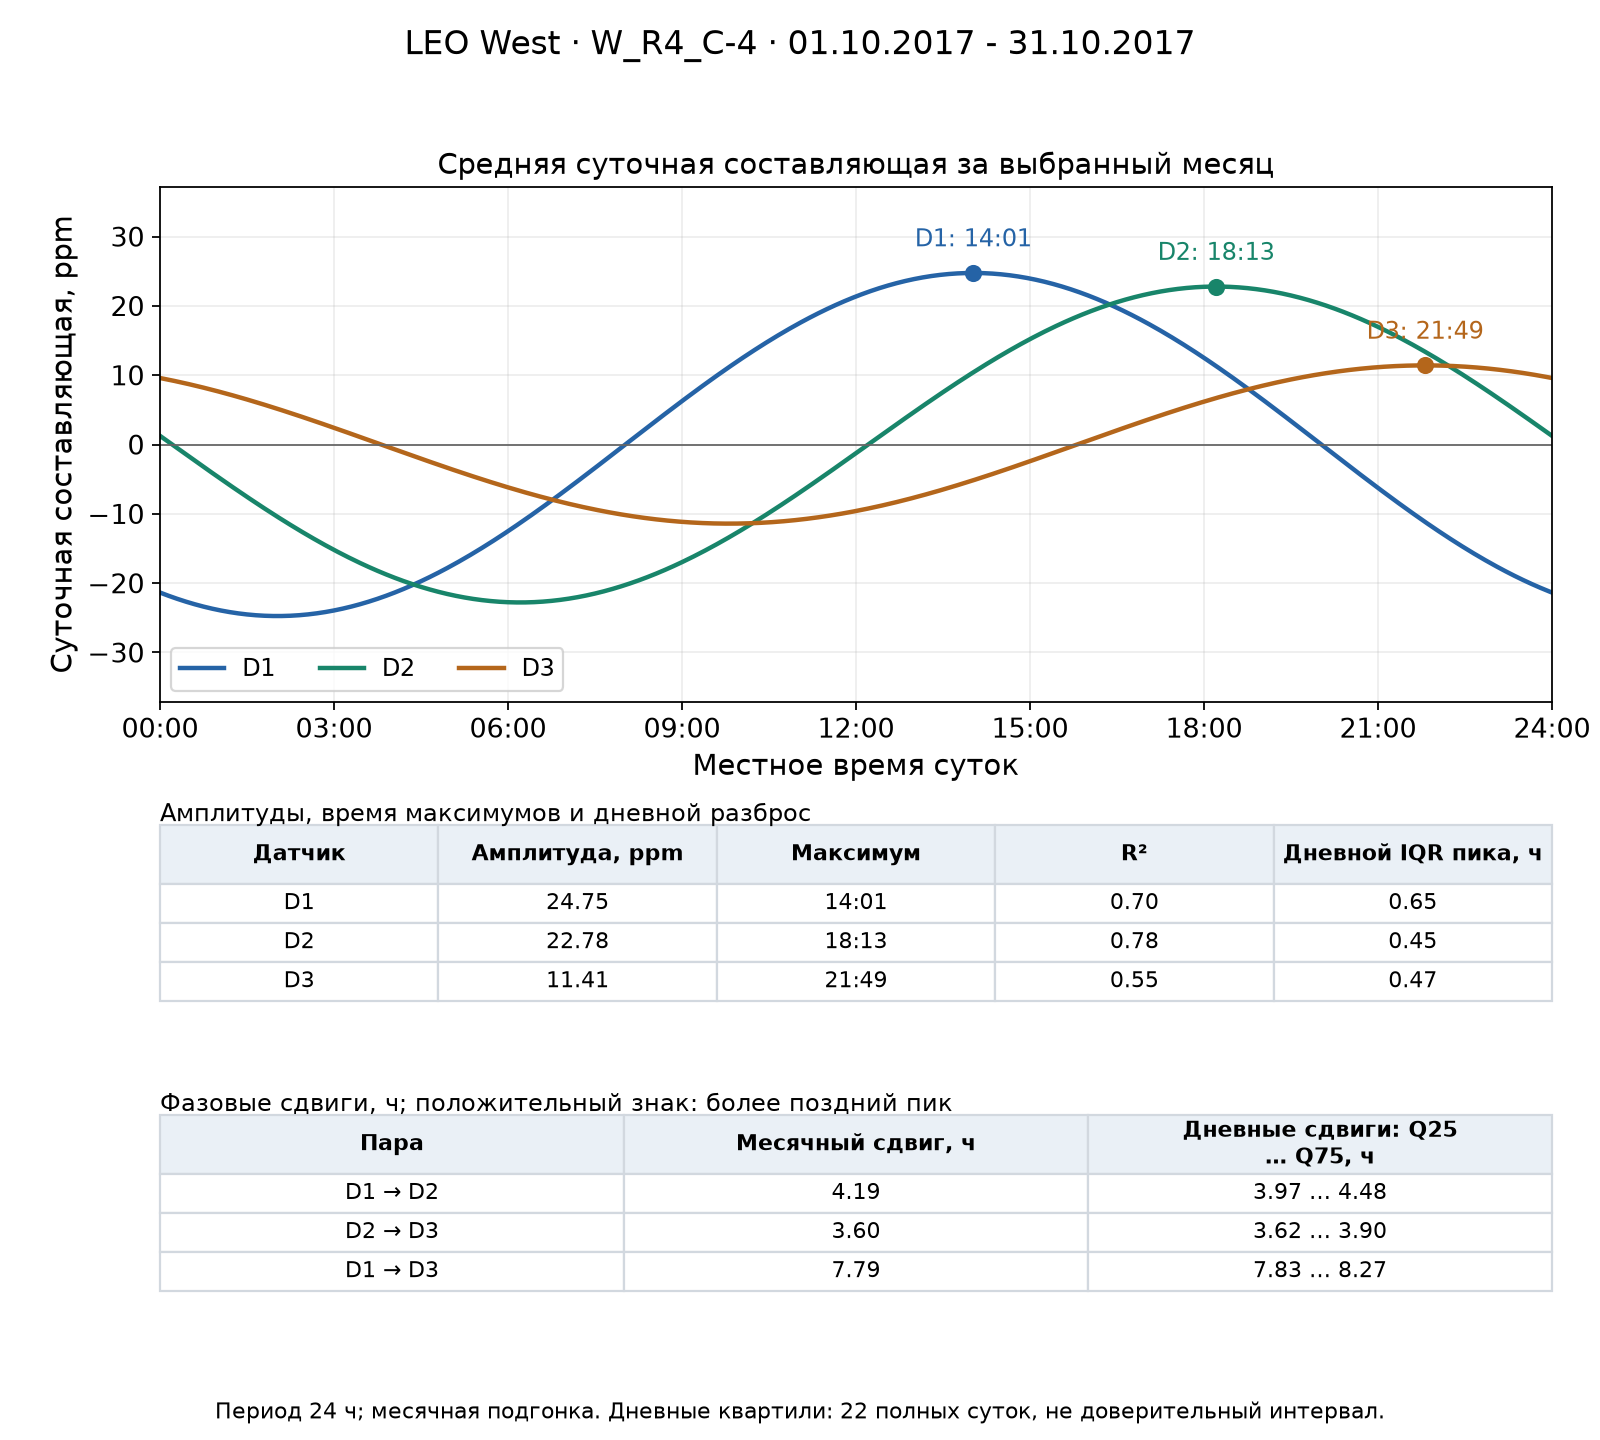

In [16]:
report.show("diurnal")

**Рисунок 1.3. Месячные волны** (без постоянного слагаемого) и сводные параметры.
Максимумы: **14:01 → 18:13 → 21:49**; амплитуда D3 - **11,41 ppm**,
примерно вдвое меньше D1 и D2. Модель описывает **70%, 78%, 55%** вариации
остатков соответственно. Это описательная подгонка, без теста значимости фазовых различий.

<a id="daily"></a>

## 1.4. Сдвиги и их дневная изменчивость

$$\Delta_{jk}=\mathrm{wrap}_{24}(h_k-h_j),\qquad
\mathrm{wrap}_{24}(u)=((u+12)\bmod24)-12.$$

Месячные сдвиги D1→D2 / D2→D3 / D1→D3: **4,19 / 3,60 / 7,79 ч**.
Для **22 полных календарных суток** модель подбирается отдельно.
IQR дневных пиков D1 / D2 / D3: **39 / 27 / 28 мин**;
квартили дневных сдвигов приведены на рисунке 1.3.

[Q25, Q75 и IQR](details/01_methods.md#quartiles) ·
[Дневные и месячные сдвиги](details/01_methods.md#phase-lags) ·
[Подробный разбор рисунка 1.4](details/01_methods.md#daily-stability)

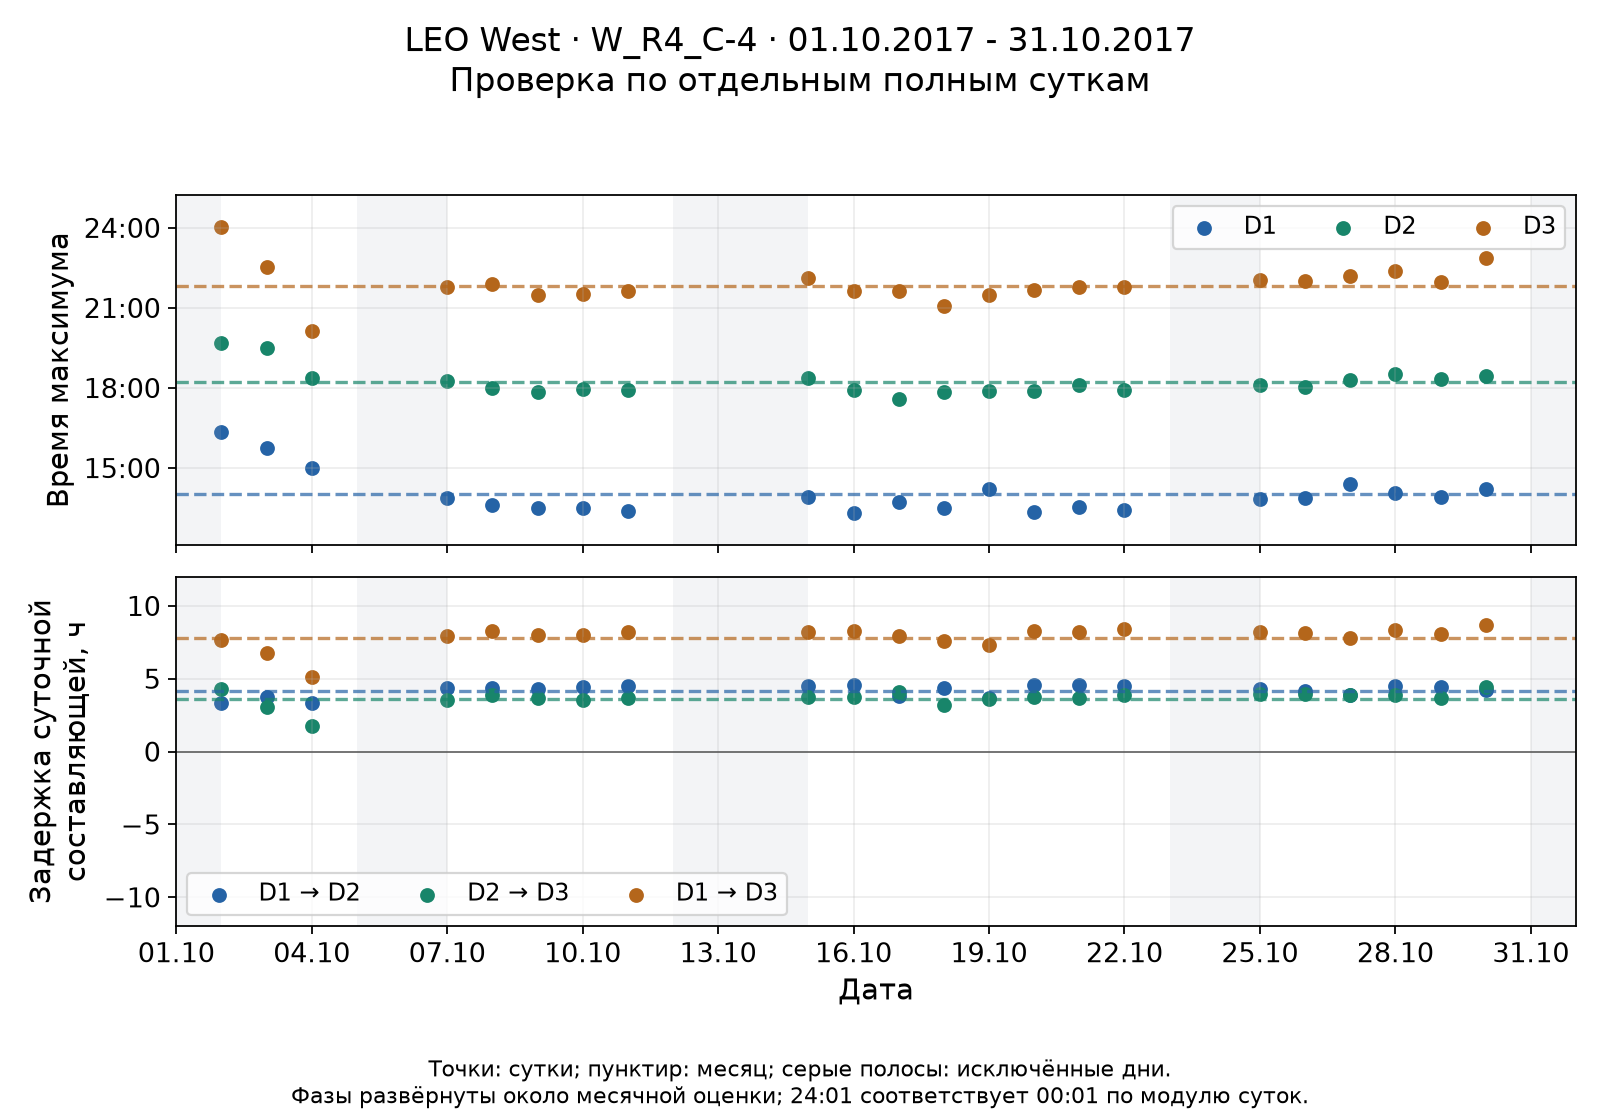

In [17]:
report.show("daily")

**Рисунок 1.4.** Сверху: времена дневных пиков; снизу: их разности.
Пунктир - месячная оценка; серым отмечены дни, исключённые по неполному покрытию.

**Начало октября отличается:** с 2 по 4 октября сдвиг D2→D3 меняется
**4,32 → 3,03 → 1,79 ч**. После 7 октября оценки в целом группируются теснее;
30 октября D1→D3 достигает **8,67 ч**. У D3 за 2 и 30 октября R² около
**0,32 и 0,36**; надёжность этих дневных фаз требует отдельной проверки.

<a id="conclusions"></a>

## 1.5. Вывод этапа

Октябрьский пример описан одной и той же 24-часовой моделью на трёх уровнях.
Получены последовательно более поздние месячные пики, меньшая амплитуда D3
и заметные дневные отклонения в начале месяца.

**Граница вывода:** неопределённость фаз и устойчивость к выбору модели пока
не оценены; IQR не заменяет доверительный интервал. Поливы и влажность ещё
не сопоставлены с сигналами. Фазовый сдвиг не отождествляется со временем
переноса CO₂; источники и коэффициент диффузии не оценивались.

[Полные ограничения и источники постановки](details/context.md)

<a id="next"></a>

## 1.6. Следующий шаг

**W_R4_C-4, D1/D2/D3, ноябрь 2017:** тот же расчёт; сравнить дневные сдвиги,
амплитуды и R² с октябрём на общей временной шкале. Затем добавить декабрь.

[Оглавление](README.md) · [Журнал](JOURNAL.md) ·
**[Далее: глава 2 - сравнение месяцев (план)](PLAN.md#chapter-2)**